## **Adversarial Attack to AI Image compression**

An AI image compression model can be represented as a Variational AutoEncoder which comprises two levels

In [ ]:
import os
import socket
import sys
import warnings
import numpy as np
import torch
from PIL import Image
from io import BytesIO
import imageio.v3 as iio
from compressai.zoo import models as compressai_models
from utils import get_device, evaluate_frequency_response2
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
warnings.filterwarnings("ignore", category=UserWarning, module="pytorch_wavelets")

device = get_device()
hostname = socket.gethostname()

CUDA available: True
GPU 0: Memory Free = 78345 MB, Temperature = 29°C
Selected GPU: 0 (Memory Free: 78345 MB, Temperature: 29°C)
Running task on GPU-0
Device set to: cuda:0


### Load Image and Compression Model

In [ ]:
BASE_DIR = "/home/nkalmykov/compressai_project/experiments"

class ImageCodecModel:
    def __init__(self, codec: str, q_level: int):
        self.codec = codec.lower()
        self.q_level = int(q_level)

    @staticmethod
    def _map_q_to_quality(q: int, codec: str) -> int:
        # Map abstract q (1..6 or 1..8) to a codec quality scale (rough heuristic)
        # JPEG/WEBP quality in [10..95]
        max_q = 6
        q = max(1, min(int(q), max_q))
        return int(np.linspace(20, 95, num=max_q)[q-1])

    def __call__(self, x: torch.Tensor):
        # x: [1,3,H,W] in [0,1]
        img = x.squeeze(0).permute(1,2,0).detach().cpu().numpy()
        img_u8 = np.clip(img * 255.0 + 0.5, 0, 255).astype(np.uint8)
        H, W, _ = img_u8.shape
        buf = BytesIO()
        q_val = self._map_q_to_quality(self.q_level, self.codec)

        if self.codec == 'jpeg':
            Image.fromarray(img_u8, mode='RGB').save(buf, format='JPEG', quality=q_val, subsampling=0, optimize=True)
            buf.seek(0)
            out = Image.open(buf).convert('RGB')
            out_u8 = np.array(out)
        elif self.codec == 'webp':
            Image.fromarray(img_u8, mode='RGB').save(buf, format='WEBP', quality=q_val, method=6)
            buf.seek(0)
            out = Image.open(buf).convert('RGB')
            out_u8 = np.array(out)
        elif self.codec == 'jpeg2000':
            # Use imageio with jp2 (requires imagecodecs)
            tmp = np.ascontiguousarray(img_u8)
            # imageio expects HxWxC uint8; set quality argument as 'quality' or 'psnr' depends on backend
            # We'll use default rate; adjust with 'codec' if needed
            with BytesIO() as b2:
                iio.imwrite(b2, tmp, extension='.jp2')
                b2.seek(0)
                out_u8 = iio.imread(b2)
            if out_u8.ndim == 2:
                out_u8 = np.stack([out_u8]*3, axis=-1)
        elif self.codec in ('jpegxl','jpeg_ai'):
            # Try imageio if built with JXL; else raise
            try:
                with BytesIO() as b2:
                    iio.imwrite(b2, img_u8, extension='.jxl')
                    b2.seek(0)
                    out_u8 = iio.imread(b2)
                if out_u8.ndim == 2:
                    out_u8 = np.stack([out_u8]*3, axis=-1)
            except Exception as e:
                raise RuntimeError("JPEG XL not available in current environment. Install imagecodecs/imageio with JXL support or provide cjxl/djxl.") from e
        else:
            raise ValueError(f"Unsupported codec: {self.codec}")

        out_f = (out_u8.astype(np.float32) / 255.0)
        x_hat = torch.from_numpy(out_f).permute(2,0,1).unsqueeze(0)
        return {"x_hat": x_hat}


def load_codec_model(codec_name: str, quality: int, device):
    return ImageCodecModel(codec_name, quality)


def load_tcm_model(p, device):
    """Load and configure the TCM model."""
    # Import the TCM model with correct path
    sys.path.append(os.path.join(BASE_DIR, "LIC_TCM-main"))

    # Map p values to checkpoint paths
    checkpoint_map = {
        128: os.path.abspath(os.path.join(BASE_DIR, "LIC_TCM-main/mse_lambda_0.05.pth.tar")),
        64: os.path.abspath(os.path.join(BASE_DIR, "LIC_TCM-main/mse_lambda_0.0025.pth.tar"))
    }

    if p not in checkpoint_map:
        raise ValueError(f"Unsupported p value: {p}. Supported values: {list(checkpoint_map.keys())}")

    # Load checkpoint
    checkpoint_path = checkpoint_map[p]
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Clean state dictionary
    state_dict = {k.replace("module.", ""): v for k, v in checkpoint["state_dict"].items()}

    # Initialize and configure model
    from models.tcm import TCM
    model = TCM(
        config=[2, 2, 2, 2, 2, 2],
        head_dim=[8, 16, 32, 32, 16, 8],
        drop_path_rate=0.0,
        N=p,
        M=320
    ).to(device).eval()

    model.load_state_dict(state_dict)
    model.update()  # Required before compression

    return model

def load_compressai_model(model_name, quality, device):
    """Load and configure a CompressAI model."""
    model_class = compressai_models.get(model_name, None)
    if not model_class:
        raise ValueError(f"Model {model_name} not found in compressai.zoo.models")

    # Clear GPU memory
    torch.cuda.empty_cache()

    # Load model and set to evaluation mode
    model = model_class(quality=quality, pretrained=True).to(device)
    
    # Disable gradients for parameters
    for param in model.parameters():
        param.requires_grad = False

    return model

# Main model loading logic
def load_model(model_name, quality, device, p=128):
    """Load the specified model based on model_name."""
    if model_name == 'tcm':
        return load_tcm_model(p, device)
    else:
        return load_compressai_model(model_name, quality, device)


# Override load_model to route to codecs as well
_prev_load_model = load_model

def load_model(model_name, quality, device, p=128):
    name = model_name.lower()
    if name in {'jpeg','jpeg2000','webp','jpegxl','jpeg_ai'}:
        return load_codec_model(name, quality, device)
    return _prev_load_model(model_name, quality, device, p=p)

In [4]:
# Batch evaluation and saving results
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import idct

# Configure experiment grids
model_range = ['cheng2020-anchor', 'cheng2020-attn', 'jpeg', 'webp'] # 'jpeg2000', 'jpeg_ai' #[] ['tcm']#
quality_range = [1, 2, 3, 4, 5, 6]
size_range = [64, 128, 256, 512, 1024]

# Where to store results
BASE_RESULTS_DIR = Path('results')
BASE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Evaluation parameters
NUM_RUNS = 100
SEED = 42
SAVE_CE_WINDOW = 2

all_runs = []

for model_name in model_range:
    for size in size_range:
        print(f"\n=== Model: {model_name} | Size: {size}x{size} ===")
        size_dir = BASE_RESULTS_DIR / model_name / str(size)
        size_dir.mkdir(parents=True, exist_ok=True)

        per_size_rows = []

        for q in quality_range:
            print(f"Evaluating quality {q}...")
            q_dir = size_dir / f"q_{q}"
            q_dir.mkdir(parents=True, exist_ok=True)

            # Load model and run evaluation (plots disabled here; we'll save explicitly below)
            model = load_model(model_name, q, device)
            x_dct_rgb, x_hat, metrics = evaluate_frequency_response2(
                model,
                size=size,
                device=device,
                show_plots=False,
                num_runs=NUM_RUNS,
                show_metric_plots=False,
                seed=SEED,
            )

            # Normalize original and decompressed DCT for saving
            mx, Mx = x_dct_rgb.min(), x_dct_rgb.max()
            denom = (Mx - mx + 1e-9)

            x_dct_norm = np.clip((x_dct_rgb - mx) / denom, 0.0, 1.0).astype(np.float32)
            x_hat_norm = np.clip((x_hat      - mx) / denom, 0.0, 1.0).astype(np.float32)

            # iDCT визуализация
            x_idct = np.zeros_like(x_hat)
            for c in range(3):
                x_idct[..., c] = idct(x_hat[..., c], axis=1, norm='ortho')
            x_idct_disp = np.clip(
                (x_idct - x_idct.min()) / (x_idct.max() - x_idct.min() + 1e-9),
                0.0, 1.0
            ).astype(np.float32)

            plt.imsave(q_dir / 'original_dct_rgb.png',     x_dct_norm)
            plt.imsave(q_dir / 'decompressed_dct_rgb.png', x_hat_norm)
            plt.imsave(q_dir / 'idct_of_decompressed_rgb.png', x_idct_disp)

            # Save metrics plots (2x3 grid)
            indices = metrics['indices']
            leakage = metrics['leakage']
            odr = metrics['odr']
            centroid_shift = metrics['centroid_shift']
            spread = metrics['spread']
            entropy_bits = metrics['entropy'] / np.log(2)
            cum_energy = metrics['cum_energy']

            fig, axs = plt.subplots(2, 3, figsize=(16, 8))
            axs[0, 0].plot(indices, leakage); axs[0, 0].set_title('Leakage L_k'); axs[0, 0].set_xlabel('k')
            axs[0, 1].plot(indices, odr); axs[0, 1].set_title('Off–diagonal ratio ODR_k'); axs[0, 1].set_xlabel('k')
            axs[0, 2].plot(indices, np.abs(centroid_shift)); axs[0, 2].set_title('Centroid shift Δc_k'); axs[0, 2].set_xlabel('k')
            axs[1, 0].plot(indices, spread); axs[1, 0].set_title('Spread s_k'); axs[1, 0].set_xlabel('k')
            axs[1, 1].plot(indices, entropy_bits); axs[1, 1].set_title('Entropy H_k (bits)'); axs[1, 1].set_xlabel('k')
            for w_key in sorted(cum_energy.keys()):
                axs[1, 2].plot(indices, cum_energy[w_key], label=f"w={w_key}")
            axs[1, 2].set_title('Cumulative energy CE_k(w)'); axs[1, 2].set_xlabel('k'); axs[1, 2].set_ylim(-0.05, 1.05); axs[1, 2].legend()
            fig.tight_layout()
            fig.savefig(q_dir / 'metrics_grid.png', dpi=150)
            plt.close(fig)

            # Save R heatmap for reference
            R = metrics['R']
            fig_hm = plt.figure(figsize=(6, 5))
            plt.imshow(R, aspect='auto', origin='lower', cmap='viridis')
            plt.colorbar(label='Normalized power')
            plt.xlabel('input basis k'); plt.ylabel('observed frequency i')
            plt.title('Frequency-response matrix R')
            fig_hm.tight_layout()
            fig_hm.savefig(q_dir / 'R_heatmap.png', dpi=150)
            plt.close(fig_hm)

            # Collect summary numbers for the per-size table
            s = metrics.get('summary', None)
            if s is None:
                # Build a summary here if not present
                ce_w = metrics['cum_energy'].get(SAVE_CE_WINDOW)
                s = {
                    'L_k': float(np.median(1.0 - np.diag(R))),
                    'ODR_k': float(np.median(odr)),
                    '|Delta_c_k|': float(np.median(np.abs(centroid_shift))),
                    's_k': float(np.median(spread)),
                    'H_k_bits': float(np.median(entropy_bits)),
                    f'CE_k(w={SAVE_CE_WINDOW})': float(np.median(ce_w)) if ce_w is not None else np.nan,
                }

            row = {'Model': model_name, 'Size': f'{size}x{size}', 'q': q}
            row.update(s)

            # Add compact band-wise summaries if available
            band = metrics.get('band_summary', None)
            if band is not None:
                try:
                    # write full per-band stats (still compact) and two gaps for trend plots
                    for bname in ['low', 'mid', 'high']:
                        b = band.get(bname, {})
                        if b:
                            row[f'{bname}_L_k'] = float(b.get('L_k', np.nan))
                            row[f'{bname}_ODR_k'] = float(b.get('ODR_k', np.nan))
                            row[f"{bname}_|Delta_c_k|_norm"] = float(b.get('|Delta_c_k|_norm', np.nan))
                            row[f'{bname}_s_k_norm'] = float(b.get('s_k_norm', np.nan))
                            row[f'{bname}_H_k_bits'] = float(b.get('H_k_bits', np.nan))
                            # CE window key name matches SAVE_CE_WINDOW
                            row[f"{bname}_CE_k(w={SAVE_CE_WINDOW})"] = float(b.get(f"CE_k(w={SAVE_CE_WINDOW})", np.nan))
                    # gap indicators
                    if all(k in band for k in ['low','high']):
                        row['gap_L_high_low'] = float(band['high'].get('L_k', np.nan)) - float(band['low'].get('L_k', np.nan))
                        row['gap_CE_low_high'] = float(band['low'].get(f"CE_k(w={SAVE_CE_WINDOW})", np.nan)) - float(band['high'].get(f"CE_k(w={SAVE_CE_WINDOW})", np.nan))
                except Exception:
                    pass

            per_size_rows.append(row)
            all_runs.append(row)

        # Save per-size CSV summary (overall metrics as before)
        df = pd.DataFrame(per_size_rows)
        df_overall_cols = ['Model', 'Size', 'q', 'L_k', 'ODR_k', '|Delta_c_k|', 's_k', 'H_k_bits', f'CE_k(w={SAVE_CE_WINDOW})']
        df = df[df_overall_cols]
        df = df.sort_values('q')
        df.round(4).to_csv(size_dir / 'metrics_summary.csv', index=False)
        print(df.round(4))

        # Save compact band-wise metrics (if present)
        df_full = pd.DataFrame(per_size_rows)
        band_cols_order = []
        for bname in ['low','mid','high']:
            band_cols_order += [
                f'{bname}_L_k',
                f'{bname}_CE_k(w={SAVE_CE_WINDOW})',
                f'{bname}_ODR_k',
                f"{bname}_|Delta_c_k|_norm",
                f'{bname}_s_k_norm',
                f'{bname}_H_k_bits',
            ]
        gap_cols = ['gap_L_high_low', 'gap_CE_low_high']
        # Keep only columns that exist
        final_cols = ['Model','Size','q'] + [c for c in band_cols_order + gap_cols if c in df_full.columns]
        if len(final_cols) > 3:
            df_bands = df_full[final_cols].sort_values('q')
            df_bands.round(4).to_csv(size_dir / 'metrics_bands_summary.csv', index=False)

# Optionally save all results in one CSV at root
if all_runs:
    df_all = pd.DataFrame(all_runs)
    df_all.round(4).to_csv(BASE_RESULTS_DIR / 'all_metrics_summary.csv', index=False)
    print("\nSaved:", BASE_RESULTS_DIR / 'all_metrics_summary.csv')



=== Model: cheng2020-anchor | Size: 64x64 ===
Evaluating quality 1...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.5783, ODR_k=1.4338, |Δc_k|=0.7962, s_k=6.0394, H_k=2.8425, CE_k(w=2)=0.7968
Evaluating quality 2...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.5115, ODR_k=1.0637, |Δc_k|=1.0120, s_k=6.3403, H_k=2.6361, CE_k(w=2)=0.8225
Evaluating quality 3...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.4792, ODR_k=0.9313, |Δc_k|=0.7777, s_k=6.0219, H_k=2.3569, CE_k(w=2)=0.8605
Evaluating quality 4...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.4711, ODR_k=1.2233, |Δc_k|=1.7377, s_k=8.5386, H_k=2.8042, CE_k(w=2)=0.7863
Evaluating quality 5...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.2726, ODR_k=0.3781, |Δc_k|=0.9242, s_k=5.8650, H_k=1.8137, CE_k(w=2)=0.9028
Evaluating quality 6...
Summary (median over k; H in bits; CE window=2; runs=100): L_k=0.3155, ODR_k=0.4719, |Δc_k|=0.9612, s_k=

In [ ]:
# Generate compact per-model/per-size tables from aggregated results
import pandas as pd
from pathlib import Path

ROOT = Path('/home/nkalmykov/compressai_project/results')
ALL_CSV = ROOT / 'all_metrics_summary.csv'
assert ALL_CSV.exists(), f"Not found: {ALL_CSV}"

cols_base = ['Model','Size','q','L_k','CE_k(w=2)']
cols_high = ['high_L_k', 'high_CE_k(w=2)']
cols_gaps = ['gap_L_high_low','gap_CE_low_high']
cols_compact = cols_base + cols_high + cols_gaps


df_all = pd.read_csv(ALL_CSV)
# Filter to available columns only
cols_present = [c for c in cols_compact if c in df_all.columns]

for (model, size), df_group in df_all.groupby(['Model','Size']):
    size_dir = ROOT / model / size.split('x')[0]
    size_dir.mkdir(parents=True, exist_ok=True)

    df_compact = df_group[cols_present].sort_values('q').reset_index(drop=True)

    # Save CSV
    out_csv = size_dir / 'metrics_compact_summary.csv'
    df_compact.round(4).to_csv(out_csv, index=False)

    # Save LaTeX table
    caption = f"Compact frequency metrics for {model} at size {size}"
    label = f"tab:compact_{model.replace('-', '_')}_{size.replace('x','x')}"
    latex = df_compact.round(4).to_latex(index=False, caption=caption, label=label, escape=False)
    (size_dir / 'metrics_compact_table.tex').write_text(latex)

print('Wrote compact tables for all model/size combinations.')


Wrote compact tables for all model/size combinations.


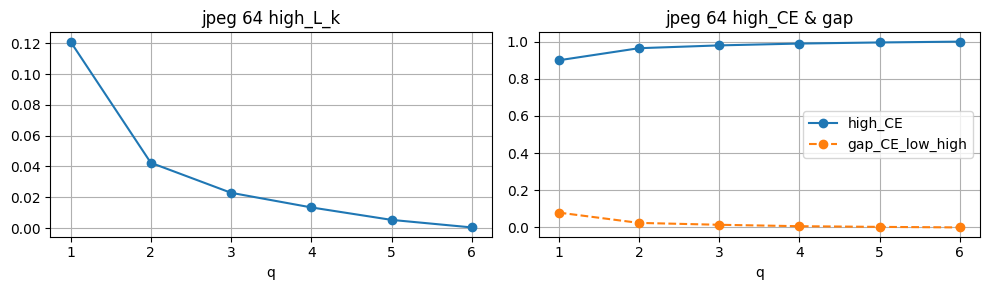

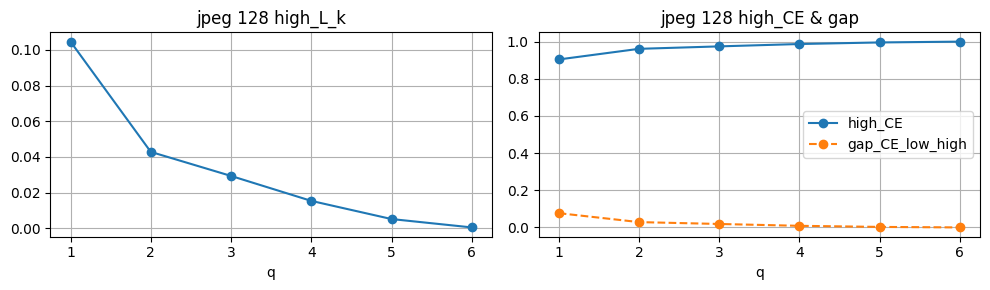

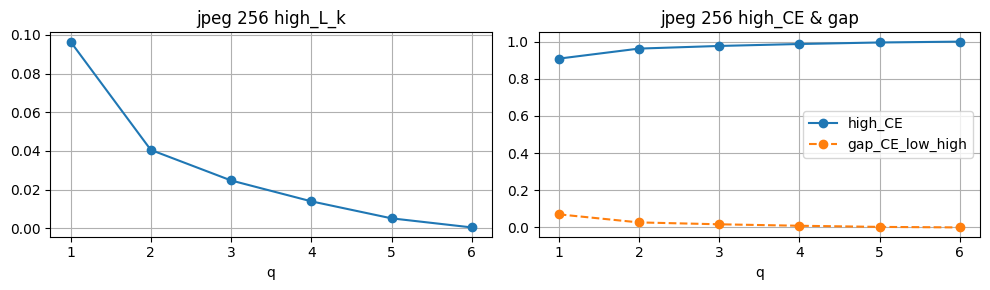

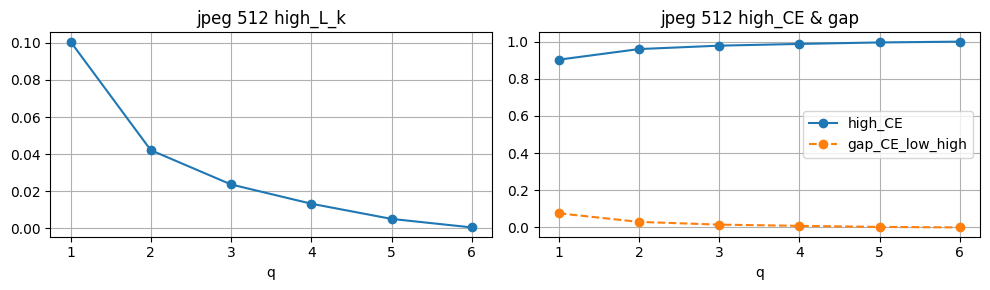

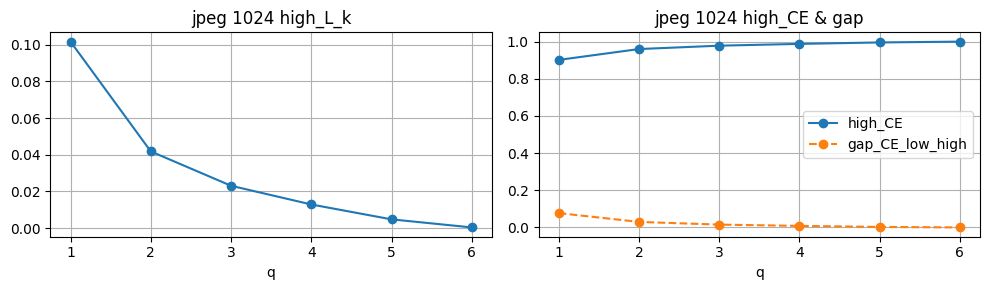

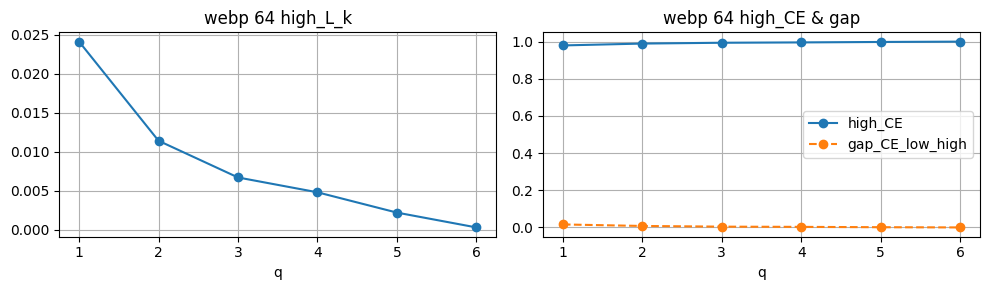

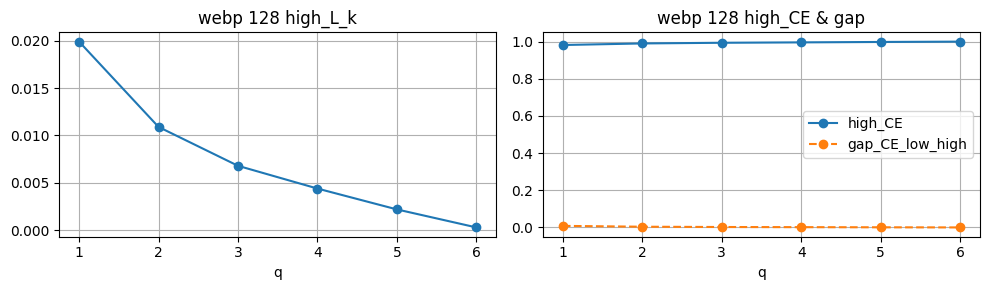

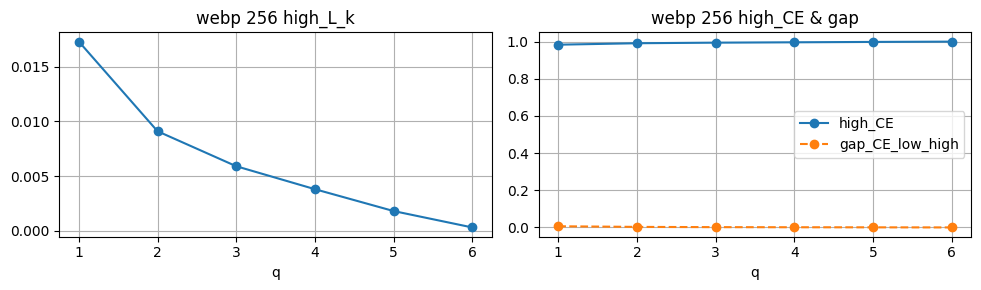

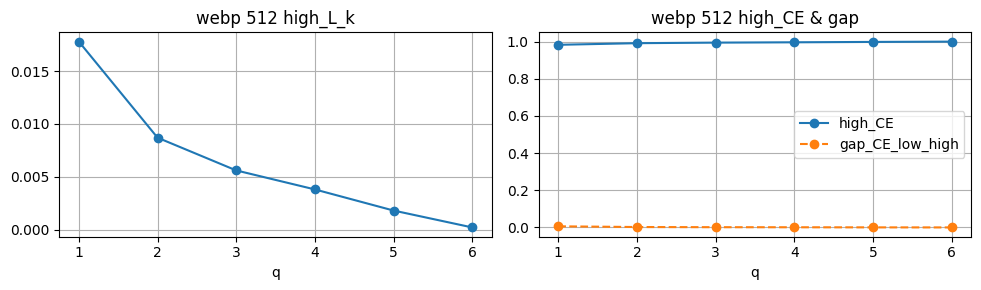

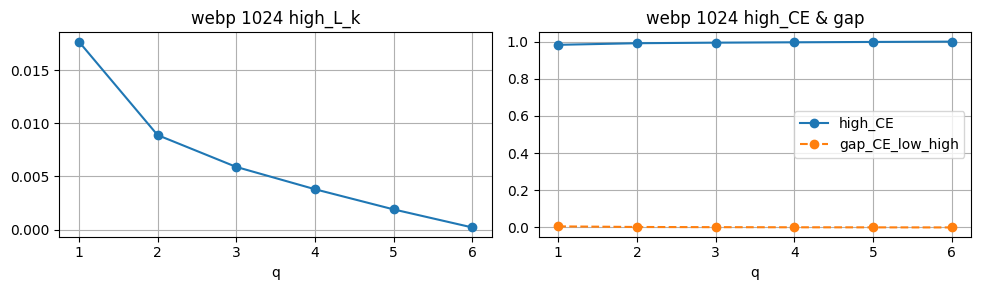

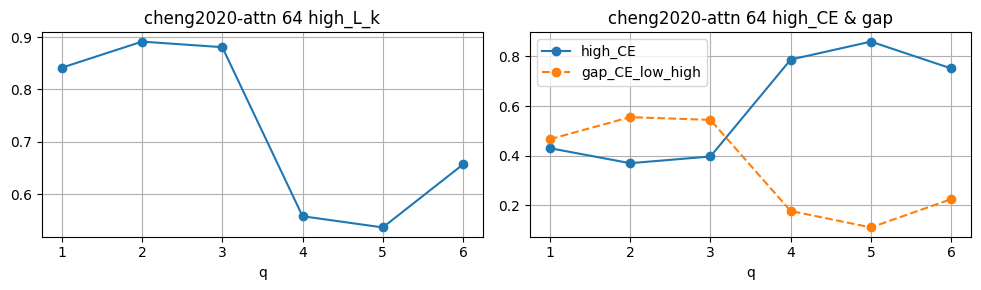

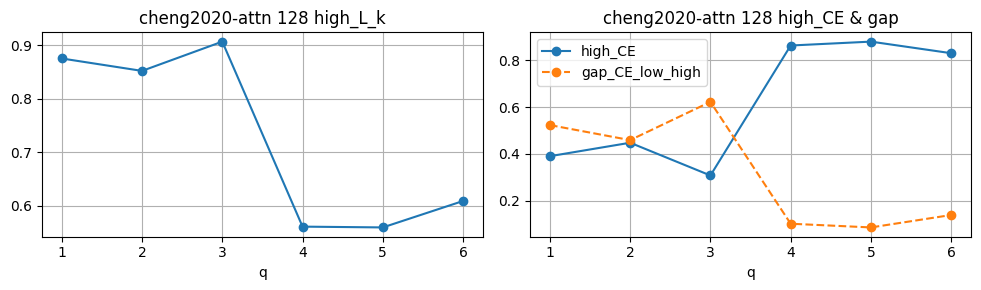

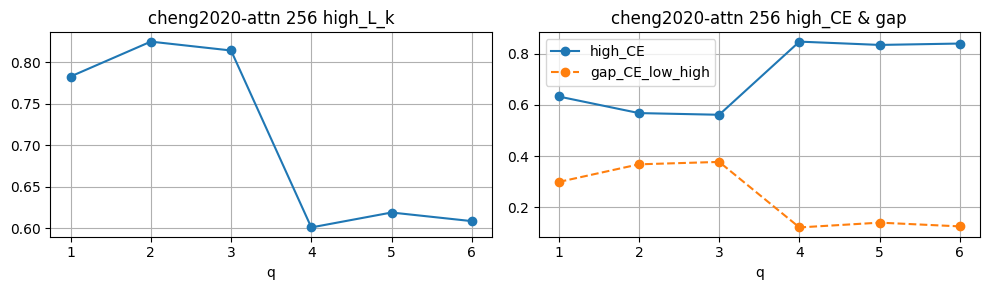

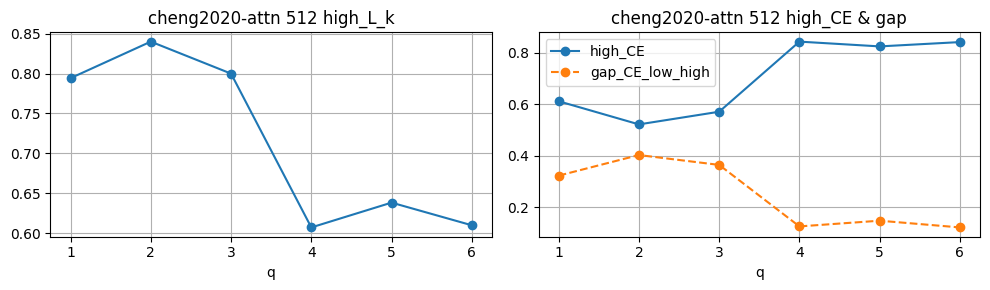

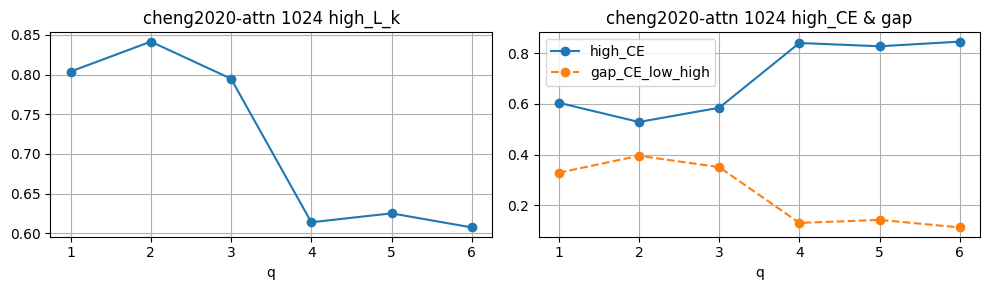

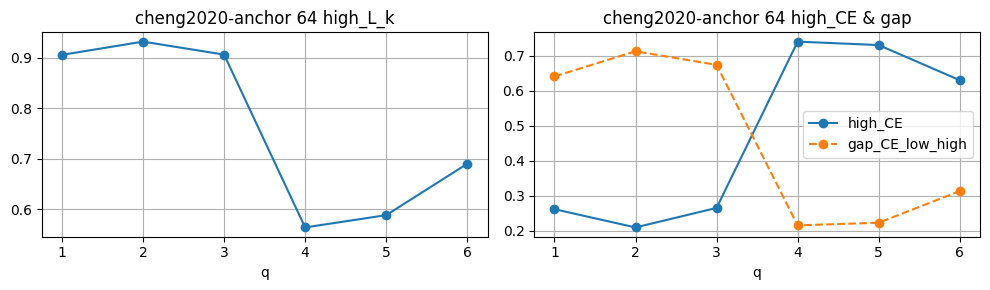

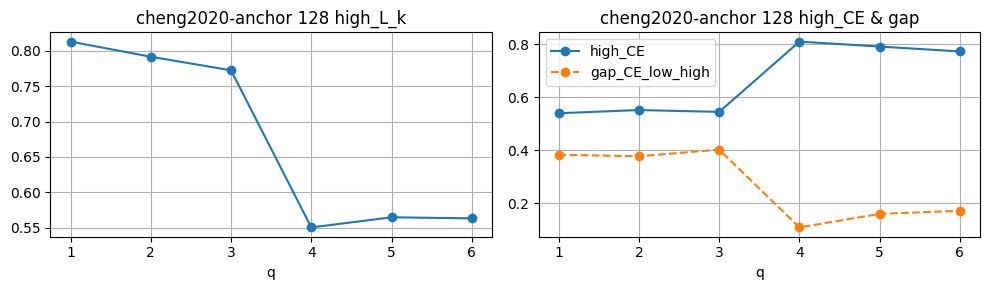

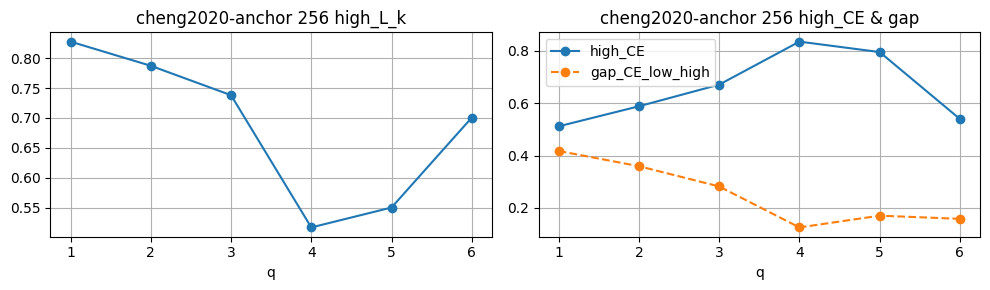

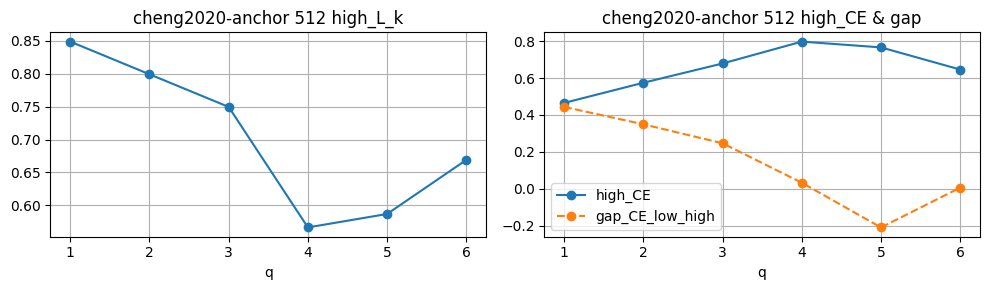

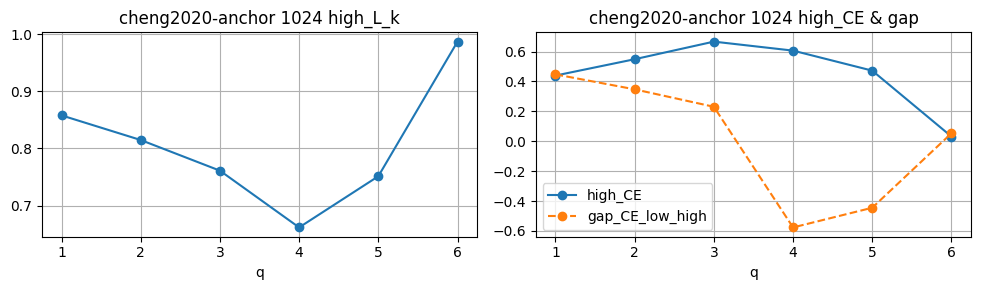

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('/home/nkalmykov/compressai_project/results')
pairs = [
    ('jpeg', ['64','128','256','512','1024']),
    ('webp', ['64','128','256','512','1024']),
    ('cheng2020-attn', ['64','128','256','512','1024']),
    ('cheng2020-anchor', ['64','128','256','512','1024']),
]
for model, sizes in pairs:
    for s in sizes:
        p = ROOT / model / s / 'metrics_compact_summary.csv'
        if not p.exists():
            continue
        df = pd.read_csv(p)
        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        ax[0].plot(df['q'], df['high_L_k'], '-o', label='high_L_k')
        ax[0].set_title(f'{model} {s} high_L_k'); ax[0].set_xlabel('q'); ax[0].grid(True)

        ax[1].plot(df['q'], df['high_CE_k(w=2)'], '-o', label='high_CE')
        if 'gap_CE_low_high' in df.columns:
            ax[1].plot(df['q'], df['gap_CE_low_high'], '--o', label='gap_CE_low_high')
        ax[1].set_title(f'{model} {s} high_CE & gap'); ax[1].set_xlabel('q'); ax[1].grid(True); ax[1].legend()
        plt.tight_layout()
        plt.show()